## 1. Imports & constants

In [21]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
from sklearn.preprocessing import StandardScaler

# ── Point Python at MoLE and STID repos (CWD = Forecasting_Baseline/) ──────
MOLE_REPO = os.path.abspath('MoLE-git')
STID_REPO = os.path.abspath('STID-git')
for p in [MOLE_REPO, STID_REPO]:
    if p not in sys.path:
        sys.path.insert(0, p)

device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')
print(f'Using device: {device}')

# ── Shared hyper-parameters ──────────────────────────────────────────────────
INPUT_LEN  = 60
OUTPUT_LEN = 12
WINDOW     = INPUT_LEN + OUTPUT_LEN
FEATURES   = ['lon', 'lat', 'alt']
MIN_LENGTH = 200
TRAIN_FRAC = 0.70
BATCH_SIZE = 512


Using device: mps


## 2. Data loading

Two separate pipelines:
- **Shared** (MoLE / STID / PatchTST): 5,828 flights, numpy + StandardScaler
- **Darts** (DLinear): 4,967 flights, `freq='10s'` enforcement

In [22]:
df = pd.read_parquet('../data/train_df.parquet')
# datetime column already present; strip timezone so DatetimeIndex ops work cleanly
df['datetime'] = pd.to_datetime(df['datetime']).dt.tz_localize(None)
print(f'Total rows: {len(df):,}  |  Unique flights: {df["track_id"].nunique():,}')


Total rows: 1,391,511  |  Unique flights: 11,395


### 2a. Shared pipeline (MoLE / STID / PatchTST)

In [23]:
train_flights, test_flights, scalers = [], [], []

for track_id, g in df.groupby('track_id'):
    g = g.sort_values('datetime').drop_duplicates(subset='datetime')
    if len(g) < MIN_LENGTH:
        continue
    vals = g[FEATURES].values.astype(np.float32)   # [T, 3]
    if np.isnan(vals).any():
        continue
    ts   = g['datetime'].values                     # [T] datetime64

    split = int(len(vals) * TRAIN_FRAC)
    scaler = StandardScaler()
    train_sc = scaler.fit_transform(vals[:split])
    test_sc  = scaler.transform(vals[split:])

    train_flights.append((train_sc, ts[:split]))
    test_flights.append((test_sc,   ts[split:]))
    scalers.append(scaler)

print(f'Flights kept (shared pipeline): {len(test_flights):,}')


Flights kept (shared pipeline): 2,340


### 2b. Darts pipeline (DLinear)

In [24]:
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler as DartsScaler
from darts.models import DLinearModel

DARTS_FREQ = '10s'

darts_series_list = []
for track_id, g in df.groupby('track_id'):
    g = g.sort_values('datetime').drop_duplicates(subset='datetime')
    if len(g) < MIN_LENGTH:
        continue
    try:
        ts = TimeSeries.from_dataframe(
            g, time_col='datetime', value_cols=FEATURES,
            freq=DARTS_FREQ, fill_missing_dates=True,
        )
        if np.isnan(ts.values()).any():
            continue
        darts_series_list.append(ts.astype(np.float32))
    except Exception:
        continue

darts_train_scaled, darts_test_scaled, darts_scalers = [], [], []
for ts in darts_series_list:
    tr, te = ts.split_before(TRAIN_FRAC)
    sc = DartsScaler()
    darts_train_scaled.append(sc.fit_transform(tr))
    darts_test_scaled.append(sc.transform(te))
    darts_scalers.append(sc)

print(f'Flights kept (Darts pipeline): {len(darts_test_scaled):,}')


Flights kept (Darts pipeline): 1,624


## 3. Metric functions

All operate on `[N, OUTPUT_LEN, 3]` numpy arrays and return a dict with keys `aggregate`, `lon`, `lat`, `alt`.

In [25]:
FEAT_NAMES = ['lon', 'lat', 'alt']

def _per_feature(arr):
    """arr shape [N, OUTPUT_LEN, 3] -> dict {aggregate: scalar, lon: scalar, lat: scalar, alt: scalar}."""
    agg = float(arr.mean())
    return {'aggregate': agg, **{f: float(arr[:, :, i].mean()) for i, f in enumerate(FEAT_NAMES)}}

def metric_mae(y_true, y_pred):
    return _per_feature(np.abs(y_true - y_pred))

def metric_mse(y_true, y_pred):
    return _per_feature((y_true - y_pred) ** 2)

def metric_rmse(y_true, y_pred):
    mse_vals = (y_true - y_pred) ** 2          # [N, 12, 3]
    rmse_per = np.sqrt(mse_vals.mean(axis=(0, 1)))   # [3]
    agg = float(np.sqrt(mse_vals.mean()))
    return {'aggregate': agg, **{f: float(rmse_per[i]) for i, f in enumerate(FEAT_NAMES)}}

def metric_smape(y_true, y_pred):
    num  = np.abs(y_true - y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    safe_denom = np.where(denom < 1e-8, 1e-8, denom)
    return _per_feature(num / safe_denom * 100.0)

def metric_mase(y_true, y_pred, raw_test_flights):
    """MASE with persistence-forecast denominator.

    Denominator = mean |y[t] - y[t-1]| across all timesteps in all test flights
    (naive 'predict last known value' baseline).
    The raw_test_flights list contains (scaled_vals [T,3], ts) tuples.
    """
    naive_errors = []
    for vals, _ in raw_test_flights:
        if len(vals) < 2:
            continue
        naive_errors.append(np.abs(np.diff(vals, axis=0)))   # [T-1, 3]
    naive_errors = np.concatenate(naive_errors, axis=0)      # [M, 3]
    denom = naive_errors.mean(axis=0)                        # [3]  per-feature
    denom = np.where(denom < 1e-8, 1e-8, denom)

    abs_err = np.abs(y_true - y_pred)                        # [N, 12, 3]
    mase_per = abs_err.mean(axis=(0, 1)) / denom             # [3]
    agg = float(abs_err.mean() / denom.mean())
    return {'aggregate': agg, **{f: float(mase_per[i]) for i, f in enumerate(FEAT_NAMES)}}

def all_metrics(y_true, y_pred, raw_test_flights):
    return {
        'MAE':   metric_mae(y_true, y_pred),
        'MSE':   metric_mse(y_true, y_pred),
        'RMSE':  metric_rmse(y_true, y_pred),
        'sMAPE': metric_smape(y_true, y_pred),
        'MASE':  metric_mase(y_true, y_pred, raw_test_flights),
    }

print('Metric functions defined.')


Metric functions defined.


## 4. Build test windows (shared pipeline)

In [26]:
def build_windows(flights):
    """Return X [N, INPUT_LEN, 3] and Y [N, OUTPUT_LEN, 3] numpy arrays."""
    xs, ys = [], []
    for vals, ts in flights:
        T = len(vals)
        for start in range(T - WINDOW + 1):
            xs.append(vals[start : start + INPUT_LEN])
            ys.append(vals[start + INPUT_LEN : start + WINDOW])
    return np.stack(xs).astype(np.float32), np.stack(ys).astype(np.float32)

X_test, Y_test = build_windows(test_flights)
print(f'X_test: {X_test.shape}   Y_test: {Y_test.shape}')


X_test: (26715, 60, 3)   Y_test: (26715, 12, 3)


## 5. Model predictor wrappers

Each class has a `.predict(X) -> np.ndarray [N, OUTPUT_LEN, 3]` interface.

### 5a. MoLE predictor

In [27]:
from models.MoLE_DLinear import Model as MoLE_DLinear

class MoLEPredictor:
    def __init__(self, path='saved_models/mole.pt'):
        ckpt = torch.load(path, map_location=device)

        class Configs:
            pass

        configs = Configs()
        for k, v in ckpt['configs'].items():
            setattr(configs, k, v)

        self.model = MoLE_DLinear(configs).to(device)
        self.model.load_state_dict(ckpt['state_dict'])
        self.model.eval()
        print(f'MoLE loaded from {path}')

    def _make_time_features(self, T):
        """Dummy uniform 10-second grid starting at epoch 0."""
        base = pd.Timestamp('1970-01-01')
        ts   = pd.DatetimeIndex([base + pd.Timedelta(seconds=10*i) for i in range(T)])
        feats = np.stack([
            ts.second      / 60.0  - 0.5,
            ts.minute      / 60.0  - 0.5,
            ts.hour        / 24.0  - 0.5,
            ts.dayofweek   / 7.0   - 0.5,
            ts.day         / 31.0  - 0.5,
        ], axis=-1).astype(np.float32)
        return feats   # [T, 5]

    def predict(self, X):
        """X: np.ndarray [N, INPUT_LEN, 3] -> np.ndarray [N, OUTPUT_LEN, 3]."""
        N = len(X)
        marks = self._make_time_features(INPUT_LEN)   # [INPUT_LEN, 5]
        xm    = np.broadcast_to(marks[None], (N, INPUT_LEN, 5)).copy()

        results = []
        for start in range(0, N, BATCH_SIZE):
            xb  = torch.tensor(X[start:start+BATCH_SIZE],  dtype=torch.float32).to(device)
            xmb = torch.tensor(xm[start:start+BATCH_SIZE], dtype=torch.float32).to(device)
            with torch.no_grad():
                out = self.model(xb, xmb)   # [B, OUTPUT_LEN, 3]
            results.append(out.cpu().numpy())
        return np.concatenate(results, axis=0)


### 5b. STID predictor

In [28]:
from stid.arch import STID

FREQ_SEC         = 10
TIME_OF_DAY_SIZE = 86400 // FREQ_SEC   # 8640
DAY_OF_WEEK_SIZE = 7

class STIDPredictor:
    def __init__(self, path='saved_models/stid.pt'):
        ckpt = torch.load(path, map_location=device)
        self.model = STID(**ckpt['model_args']).to(device)
        self.model.load_state_dict(ckpt['state_dict'])
        self.model.eval()
        print(f'STID loaded from {path}')

    def _make_temporal(self, T):
        """Dummy uniform 10-second grid: tod and dow both [0,1)."""
        base    = pd.Timestamp('1970-01-01')
        ts      = pd.DatetimeIndex([base + pd.Timedelta(seconds=10*i) for i in range(T)])
        sec_day = np.array(ts.hour * 3600 + ts.minute * 60 + ts.second, dtype=np.float32)
        tod     = (sec_day / 86400.0).astype(np.float32)   # plain numpy [T]
        dow     = np.array(ts.dayofweek, dtype=np.float32) / 7.0  # plain numpy [T]
        return tod, dow

    def predict(self, X):
        """X: [N, INPUT_LEN, 3] -> [N, OUTPUT_LEN, 3]."""
        N        = len(X)
        tod, dow = self._make_temporal(INPUT_LEN)   # plain numpy [INPUT_LEN]

        results = []
        for start in range(0, N, BATCH_SIZE):
            batch = np.asarray(X[start:start+BATCH_SIZE], dtype=np.float32)  # [B, 60, 3]
            B     = len(batch)
            # Expand tod/dow: [INPUT_LEN] -> [B, INPUT_LEN, 3]
            tod_b = np.broadcast_to(tod[np.newaxis, :, np.newaxis], (B, INPUT_LEN, 3)).copy()
            dow_b = np.broadcast_to(dow[np.newaxis, :, np.newaxis], (B, INPUT_LEN, 3)).copy()
            # Add channel dim -> [B, 60, 3, 1] then concat -> [B, 60, 3, 3]
            val_b = batch[:, :, :, np.newaxis]          # [B, 60, 3, 1]
            tod_b = tod_b[:, :, :, np.newaxis]          # [B, 60, 3, 1]
            dow_b = dow_b[:, :, :, np.newaxis]          # [B, 60, 3, 1]
            xb    = np.concatenate([val_b, tod_b, dow_b], axis=-1)  # [B, 60, 3, 3]

            xb_t = torch.tensor(xb, dtype=torch.float32).to(device)
            with torch.no_grad():
                out = self.model(
                    history_data=xb_t,
                    future_data=None,
                    batch_seen=0, epoch=0, train=False,
                )   # [B, 12, 3, 1]
            results.append(out.squeeze(-1).cpu().numpy())   # [B, 12, 3]
        return np.concatenate(results, axis=0)


### 5c. PatchTST predictor

In [29]:
from transformers import PatchTSTForPrediction

class PatchTSTPredictor:
    def __init__(self, path='saved_models/patchtst/'):
        self.model = PatchTSTForPrediction.from_pretrained(path).to(device)
        self.model.eval()
        print(f'PatchTST loaded from {path}')

    def predict(self, X):
        """X: [N, INPUT_LEN, 3] -> [N, OUTPUT_LEN, 3]."""
        results = []
        for start in range(0, len(X), BATCH_SIZE):
            xb = torch.tensor(X[start:start+BATCH_SIZE], dtype=torch.float32).to(device)
            with torch.no_grad():
                out = self.model(past_values=xb)
            results.append(out.prediction_outputs.cpu().numpy())   # [B, 12, 3]
        return np.concatenate(results, axis=0)


### 5d. DLinear predictor (Darts)

In [30]:
class DLinearPredictor:
    """Evaluates using the Darts pipeline (4,967 flights, freq-enforced).
    Returns a flat [N_FLIGHTS, OUTPUT_LEN, 3] array where each row is one flight's
    single forecast (context = last INPUT_LEN steps of the training series).
    """
    def __init__(self, path='saved_models/dlinear'):
        self.model = DLinearModel.load(path)
        print(f'DLinear loaded from {path}')

    def predict_darts(self, train_series_scaled, test_series_scaled):
        """
        Returns y_pred [N, OUTPUT_LEN, 3] and y_true [N, OUTPUT_LEN, 3]
        using the same evaluation protocol as Dlinear.ipynb:
        context = last INPUT_LEN steps of the *training* series.
        """
        y_preds, y_trues = [], []
        for tr, te in zip(train_series_scaled, test_series_scaled):
            if len(te) < OUTPUT_LEN:
                continue
            context     = tr[-INPUT_LEN:]
            forecast_sc = self.model.predict(n=OUTPUT_LEN, series=context)
            y_preds.append(forecast_sc.values())        # [OUTPUT_LEN, 3]
            y_trues.append(te[:OUTPUT_LEN].values())    # [OUTPUT_LEN, 3]
        y_pred = np.stack(y_preds).astype(np.float32)   # [N, 12, 3]
        y_true = np.stack(y_trues).astype(np.float32)
        return y_pred, y_true


## 6. `evaluate_model` helper

In [31]:
def evaluate_model(predictor, X_test, Y_test, raw_test_flights):
    """Run inference and compute all 5 metrics.

    Parameters
    ----------
    predictor       : object with .predict(X) -> np.ndarray [N, 12, 3]
    X_test          : np.ndarray [N, INPUT_LEN, 3]
    Y_test          : np.ndarray [N, OUTPUT_LEN, 3]
    raw_test_flights: list of (scaled_vals [T,3], ts) — used for MASE denominator

    Returns
    -------
    dict  metric_name -> {aggregate, lon, lat, alt}
    """
    print(f'Running inference on {len(X_test):,} windows...')
    Y_pred = predictor.predict(X_test)
    print(f'Y_pred shape: {Y_pred.shape}')
    return all_metrics(Y_test, Y_pred, raw_test_flights)


## 7. `compare_models` — build comparison table

In [32]:
METRIC_NAMES = ['MAE', 'MSE', 'RMSE', 'sMAPE', 'MASE']
ROW_LEVELS   = ['aggregate', 'lon', 'lat', 'alt']

def compare_models(results_dict):
    """
    Parameters
    ----------
    results_dict : dict  model_name -> metrics_dict
                   (metrics_dict is the output of evaluate_model / all_metrics)

    Returns
    -------
    pd.DataFrame  rows = MultiIndex(model, feature_level)
                  cols = 5 metrics
    """
    rows = []
    index_tuples = []
    for model_name, metrics in results_dict.items():
        for level in ROW_LEVELS:
            row = [metrics[m][level] for m in METRIC_NAMES]
            rows.append(row)
            index_tuples.append((model_name, level))

    idx = pd.MultiIndex.from_tuples(index_tuples, names=['Model', 'Feature'])
    df  = pd.DataFrame(rows, index=idx, columns=METRIC_NAMES)
    return df

def style_table(df):
    """Colour-grade each numeric column independently (lower = greener)."""
    return (
        df.style
          .background_gradient(cmap='RdYlGn_r', axis=0)
          .format('{:.5f}')
          .set_caption('Model comparison — scaled metrics (lower is better)')
    )


## 8. Run evaluation

> **Before running this section**, make sure all models have been saved by executing the final cell of each training notebook.
>
> Expected saved files:
> - `saved_models/mole.pt`
> - `saved_models/stid.pt`
> - `saved_models/patchtst/` (directory)
> - `saved_models/dlinear` (Darts format)

In [33]:
results = {}

# ── MoLE ─────────────────────────────────────────────────────────────────────
print('=== MoLE ===')
mole_pred = MoLEPredictor('saved_models/mole.pt')
results['MoLE'] = evaluate_model(mole_pred, X_test, Y_test, test_flights)


=== MoLE ===
MoLE loaded from saved_models/mole.pt
Running inference on 26,715 windows...
Y_pred shape: (26715, 12, 3)


In [34]:
# ── STID ─────────────────────────────────────────────────────────────────────
print('=== STID ===')
stid_pred = STIDPredictor('saved_models/stid.pt')
results['STID'] = evaluate_model(stid_pred, X_test, Y_test, test_flights)


=== STID ===
STID loaded from saved_models/stid.pt
Running inference on 26,715 windows...
Y_pred shape: (26715, 12, 3)


In [35]:
# ── PatchTST ─────────────────────────────────────────────────────────────────
print('=== PatchTST ===')
patchtst_pred = PatchTSTPredictor('saved_models/patchtst/')
results['PatchTST'] = evaluate_model(patchtst_pred, X_test, Y_test, test_flights)


=== PatchTST ===
PatchTST loaded from saved_models/patchtst/
Running inference on 26,715 windows...
Y_pred shape: (26715, 12, 3)


In [36]:
# ── DLinear (Darts — separate pipeline, 4,967 flights) ───────────────────────
# Note: DLinear uses freq-enforced TimeSeries objects; its flight count differs
# from the other three models (4,967 vs 5,828).  Metrics are still comparable
# because they are computed on scaled values with the same normalisation scheme.
print('=== DLinear ===')
dlinear_pred = DLinearPredictor('saved_models/dlinear')
dl_y_pred, dl_y_true = dlinear_pred.predict_darts(darts_train_scaled, darts_test_scaled)

# Build raw_test_flights list for MASE denominator (darts pipeline)
darts_raw_test = []
for ts in darts_series_list:
    _, te_raw = ts.split_before(TRAIN_FRAC)
    vals = te_raw.values().astype(np.float32)
    darts_raw_test.append((vals, None))

results['DLinear*'] = all_metrics(dl_y_true, dl_y_pred, darts_raw_test)
print('(* DLinear evaluated on 4,967 Darts flights vs 5,828 for others)')


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


=== DLinear ===
DLinear loaded from saved_models/dlinear


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

...

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

(* DLinear evaluated on 4,967 Darts flights vs 5,828 for others)


In [37]:
# ── Print numeric summary ─────────────────────────────────────────────────────
df_results = compare_models(results)
print(df_results.to_string())


                           MAE           MSE         RMSE       sMAPE        MASE
Model    Feature                                                                 
MoLE     aggregate   25.407784  5.355808e+04   231.426193   34.900517   18.139414
         lon          0.387231  4.272678e-01     0.653657   18.035425   13.836674
         lat          0.441127  3.374942e-01     0.580942   18.471144   11.586550
         alt         75.394997  1.606735e+05   400.837463   68.194977   18.228842
STID     aggregate   71.532875  3.706820e+05   608.836609  184.850739   51.069565
         lon          2.918790  3.680759e+01     6.066831  182.957962  104.290802
         lat          3.397744  1.824522e+01     4.271316  192.183762   89.246773
         alt        208.282120  1.111991e+06  1054.474854  179.410599   50.319454
PatchTST aggregate   60.917530  2.722505e+05   521.776306   71.252914   43.490936
         lon          1.154371  2.375533e+01     4.873863   41.003574   41.248398
         lat    

In [38]:
# ── Styled table ──────────────────────────────────────────────────────────────
style_table(df_results)


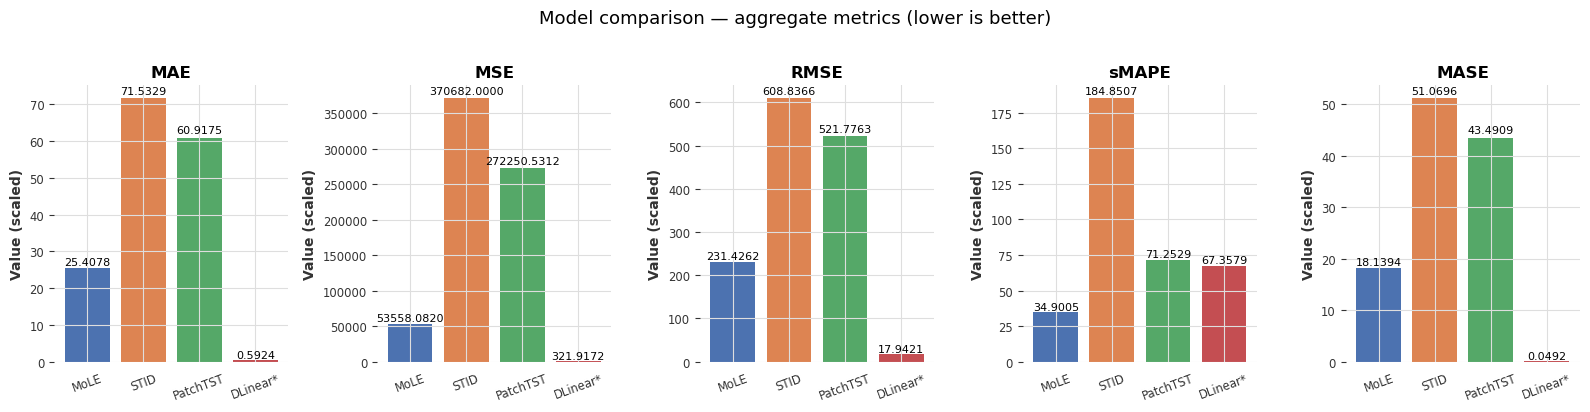

In [39]:
# ── Bar chart: aggregate metrics per model ────────────────────────────────────
agg_df = df_results.xs('aggregate', level='Feature')

fig, axes = plt.subplots(1, len(METRIC_NAMES), figsize=(16, 4), sharey=False)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, metric in zip(axes, METRIC_NAMES):
    vals   = agg_df[metric]
    bars   = ax.bar(vals.index, vals.values, color=colors[:len(vals)])
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value (scaled)')
    ax.tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Model comparison — aggregate metrics (lower is better)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 9. Real-time flight simulation

Simulates live inference as if receiving the flight step-by-step:

1. Start with the first `INPUT_LEN` steps as the initial context.
2. Run a forecast → predict the next `PRED_EVERY` steps.
3. Reveal the next `PRED_EVERY` true steps, append them to the known history.
4. Repeat until the end of the flight.

Each forecast fan is plotted over the ground truth, coloured from early (dark) to late (bright).

**Parameters:**
| Variable | Default | Meaning |
|---|---|---|
| `SIM_PREDICTOR` | `'patchtst'` | Model: `'mole'`, `'stid'`, `'patchtst'` |
| `SIM_FLIGHT_IDX` | `0` | Index into `test_flights` |
| `PRED_EVERY` | `6` | Steps revealed between forecasts (× 10 s = cadence) |


In [44]:
# ── Simulation parameters ────────────────────────────────────────────────────
SIM_PREDICTOR  = 'patchtst'   # 'mole' | 'stid' | 'patchtst'
SIM_FLIGHT_IDX = 0            # index into test_flights (sorted by length descending)
PRED_EVERY     = 6            # steps revealed between forecasts  (× 10 s)

# ── Load model ───────────────────────────────────────────────────────────────
_pred_paths = {
    'mole':     ('saved_models/mole.pt',     MoLEPredictor),
    'stid':     ('saved_models/stid.pt',     STIDPredictor),
    'patchtst': ('saved_models/patchtst/',   PatchTSTPredictor),
}
assert SIM_PREDICTOR in _pred_paths, f"SIM_PREDICTOR must be one of {list(_pred_paths)}"
_path, _cls = _pred_paths[SIM_PREDICTOR]
sim_pred = _cls(_path)

# ── Pick a long flight ───────────────────────────────────────────────────────
sim_flights_long = sorted(
    [(v, ts) for v, ts in test_flights if len(v) >= INPUT_LEN + PRED_EVERY],
    key=lambda x: -len(x[0])
)
assert SIM_FLIGHT_IDX < len(sim_flights_long), (
    f"SIM_FLIGHT_IDX={SIM_FLIGHT_IDX} out of range ({len(sim_flights_long)} long flights)")

sim_vals, sim_ts = sim_flights_long[SIM_FLIGHT_IDX]
T_sim = len(sim_vals)
print(f'Flight length : {T_sim} steps  ({T_sim * 10} s)')
print(f'Model         : {SIM_PREDICTOR}')
print(f'Predict every : {PRED_EVERY} steps  ({PRED_EVERY * 10} s)')
print(f'Forecast fans : {(T_sim - INPUT_LEN) // PRED_EVERY}')


PatchTST loaded from saved_models/patchtst/
Flight length : 108 steps  (1080 s)
Model         : patchtst
Predict every : 6 steps  (60 s)
Forecast fans : 8


In [45]:
# ── Simulation loop ──────────────────────────────────────────────────────────
# forecasts: list of (origin_step, y_pred [OUTPUT_LEN, 3])
# origin_step = index of the first predicted step (= end of context so far)
forecasts = []

# We start with INPUT_LEN steps revealed, then reveal PRED_EVERY at a time
for origin in range(INPUT_LEN, T_sim, PRED_EVERY):
    # Context = everything known so far, capped to last INPUT_LEN steps
    ctx_start = max(0, origin - INPUT_LEN)
    ctx       = sim_vals[ctx_start:origin]              # [INPUT_LEN, 3]

    # Pad with first value if context is shorter than INPUT_LEN (only for the
    # very first window when origin < 2*INPUT_LEN — shouldn't happen here)
    if len(ctx) < INPUT_LEN:
        pad = np.repeat(ctx[:1], INPUT_LEN - len(ctx), axis=0)
        ctx = np.concatenate([pad, ctx], axis=0)

    xb     = ctx[np.newaxis].astype(np.float32)         # [1, INPUT_LEN, 3]
    y_pred = sim_pred.predict(xb)[0]                    # [OUTPUT_LEN, 3]
    forecasts.append((origin, y_pred))

print(f'Generated {len(forecasts)} forecast fans.')


Generated 8 forecast fans.


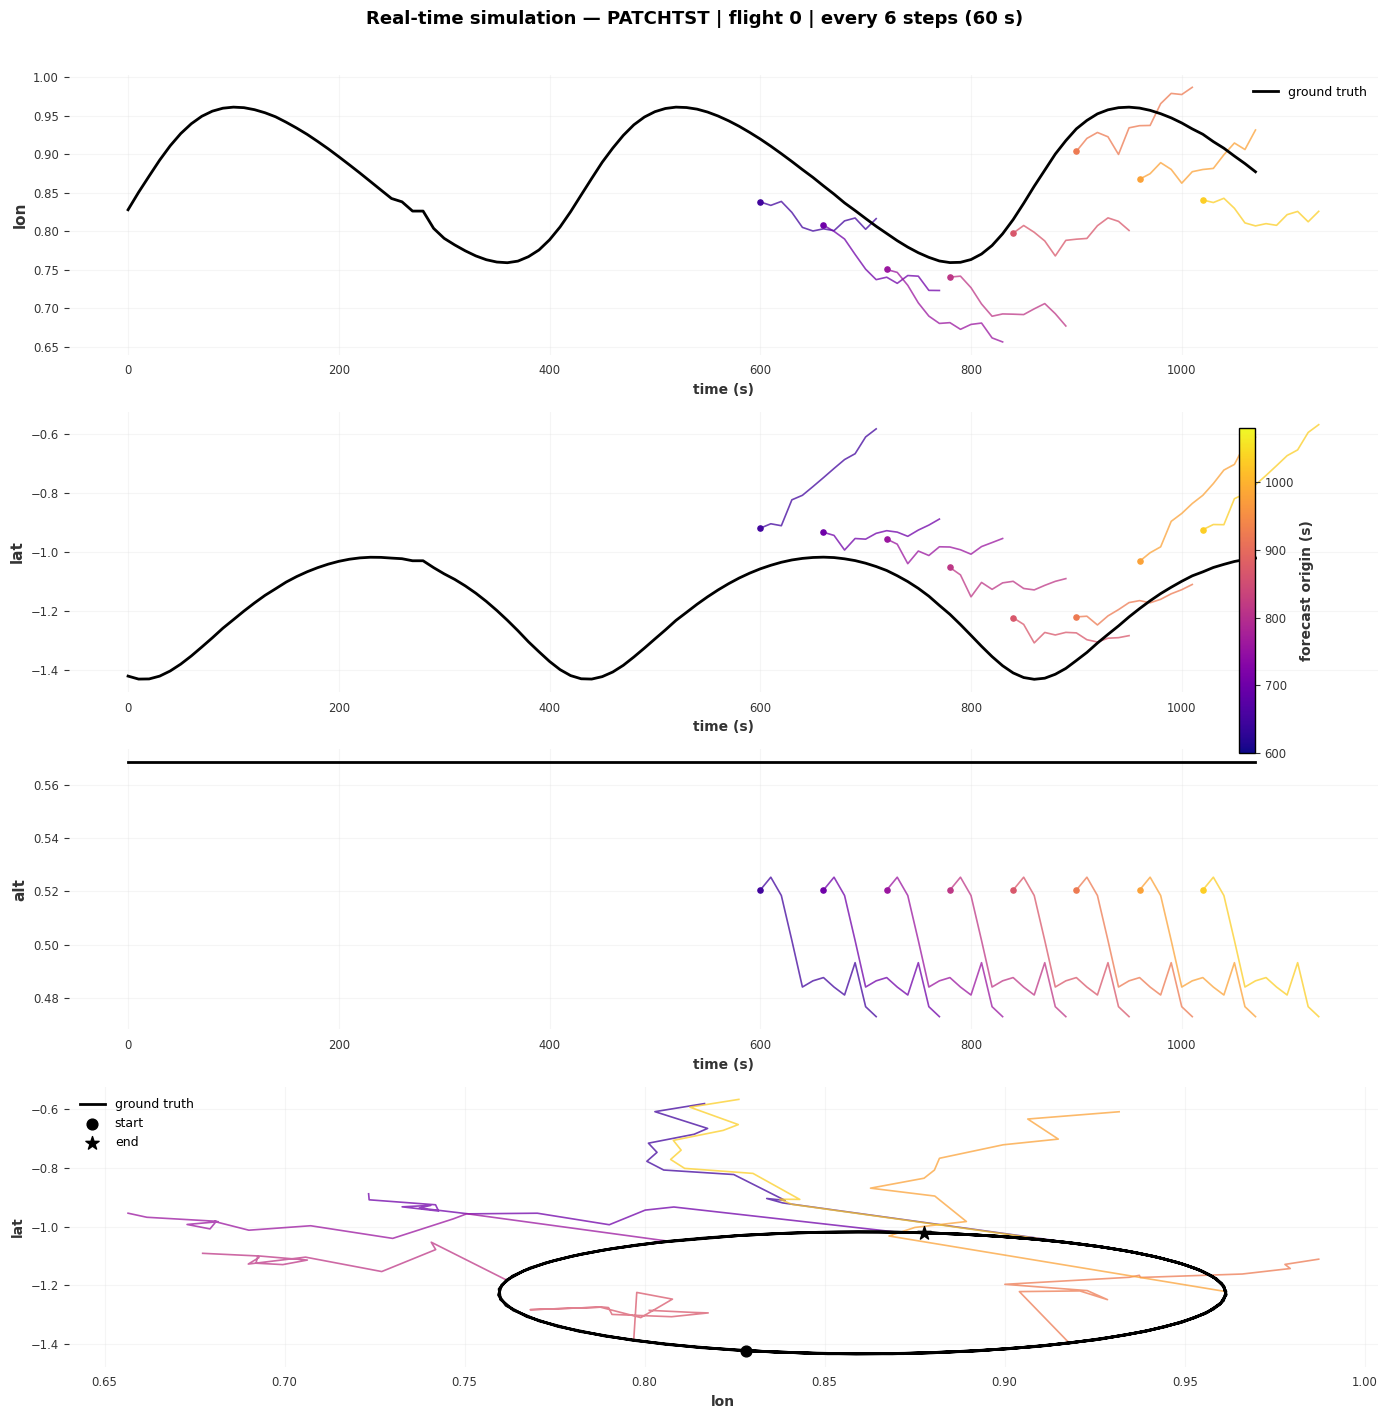

In [46]:
# ── Plot: per-feature time series + 2-D trajectory ───────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

time_axis = np.arange(T_sim) * 10   # wall-clock seconds

fig, axes = plt.subplots(4, 1, figsize=(14, 14))
ax_lon, ax_lat, ax_alt, ax_traj = axes

# Ground truth
for ax, fi, fn in zip([ax_lon, ax_lat, ax_alt], [0, 1, 2], ['lon', 'lat', 'alt']):
    ax.plot(time_axis, sim_vals[:, fi], color='black', linewidth=2,
            label='ground truth', zorder=5)
    ax.set_ylabel(fn, fontsize=11)
    ax.set_xlabel('time (s)')
    ax.grid(True, alpha=0.3)

ax_traj.plot(sim_vals[:, 0], sim_vals[:, 1], color='black', linewidth=2,
             label='ground truth', zorder=5)
ax_traj.scatter(sim_vals[0, 0],  sim_vals[0, 1],  color='black', s=60, zorder=6,
                label='start')
ax_traj.scatter(sim_vals[-1, 0], sim_vals[-1, 1], color='black', s=100,
                marker='*', zorder=6, label='end')
ax_traj.set_xlabel('lon'); ax_traj.set_ylabel('lat')
ax_traj.grid(True, alpha=0.3)

# Colour fans early→late
colors = cm.plasma(np.linspace(0.1, 0.9, len(forecasts)))

for (origin, y_pred), color in zip(forecasts, colors):
    t_future = (np.arange(OUTPUT_LEN) + origin) * 10   # seconds

    for ax, fi in zip([ax_lon, ax_lat, ax_alt], [0, 1, 2]):
        ax.plot(t_future, y_pred[:, fi], color=color, alpha=0.75, linewidth=1.2)
        ax.scatter(t_future[0], y_pred[0, fi], color=color, s=14, zorder=4)

    bridge_lon = [sim_vals[origin - 1, 0]] + list(y_pred[:, 0])
    bridge_lat = [sim_vals[origin - 1, 1]] + list(y_pred[:, 1])
    ax_traj.plot(bridge_lon, bridge_lat, color=color, alpha=0.75, linewidth=1.2)

# Shared colorbar for fan timing
sm = ScalarMappable(cmap='plasma',
                    norm=Normalize(vmin=INPUT_LEN * 10, vmax=T_sim * 10))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:3], fraction=0.015, pad=0.02)
cbar.set_label('forecast origin (s)', fontsize=10)

ax_lon.legend(loc='upper right', fontsize=9)
ax_traj.legend(loc='upper left', fontsize=9)

fig.suptitle(
    f'Real-time simulation — {SIM_PREDICTOR.upper()} | flight {SIM_FLIGHT_IDX} | '
    f'every {PRED_EVERY} steps ({PRED_EVERY * 10} s)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


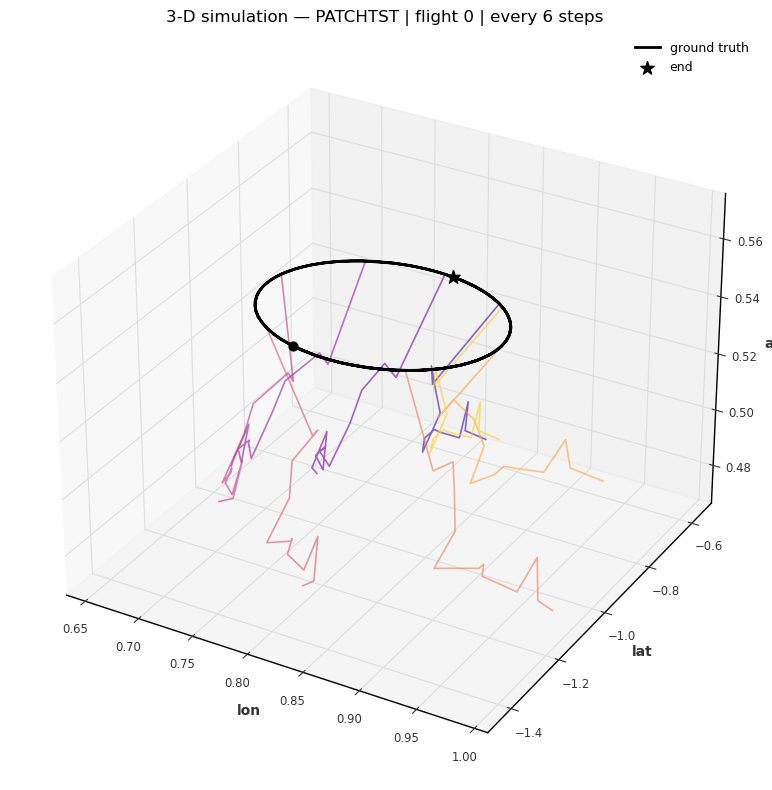

In [47]:
# ── 3-D trajectory plot ───────────────────────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig3 = plt.figure(figsize=(12, 8))
ax3  = fig3.add_subplot(111, projection='3d')

ax3.plot(sim_vals[:, 0], sim_vals[:, 1], sim_vals[:, 2],
         color='black', linewidth=2, label='ground truth', zorder=5)
ax3.scatter(*sim_vals[0],  color='black', s=40,  zorder=6)
ax3.scatter(*sim_vals[-1], color='black', s=100, marker='*', zorder=6, label='end')

for (origin, y_pred), color in zip(forecasts, colors):
    bridge_lon = [sim_vals[origin - 1, 0]] + list(y_pred[:, 0])
    bridge_lat = [sim_vals[origin - 1, 1]] + list(y_pred[:, 1])
    bridge_alt = [sim_vals[origin - 1, 2]] + list(y_pred[:, 2])
    ax3.plot(bridge_lon, bridge_lat, bridge_alt, color=color, alpha=0.6, linewidth=1.2)

ax3.set_xlabel('lon'); ax3.set_ylabel('lat'); ax3.set_zlabel('alt')
ax3.set_title(
    f'3-D simulation — {SIM_PREDICTOR.upper()} | flight {SIM_FLIGHT_IDX} | '
    f'every {PRED_EVERY} steps',
    fontsize=12
)
ax3.legend(fontsize=9)
plt.tight_layout()
plt.show()
